## 📦 Step 0: Install & Import Libraries

In [1]:
# Install required libraries (run once)
# !pip install scikit-learn pandas numpy

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Dataset: Job Roles with their required skills
# In a real project this would be loaded from raw_skills.csv

data = {
    'job_role': [
        'Data Scientist',
        'Machine Learning Engineer',
        'Data Analyst',
        'AI Research Scientist',
        'Backend Developer',
        'Frontend Developer',
        'Full Stack Developer',
        'DevOps Engineer',
        'Cloud Architect',
        'Cybersecurity Analyst',
        'Mobile App Developer',
        'Database Administrator',
        'Software Engineer',
        'NLP Engineer',
        'Computer Vision Engineer',
        'System Administrator',
        'Business Intelligence Developer',
        'Robotics Engineer',
        'Blockchain Developer',
        'Game Developer'
    ],
    'skills': [
        'python sql machine learning statistics data analysis pandas numpy visualization scikit-learn',
        'python tensorflow pytorch machine learning deep learning neural networks algorithms optimization model deployment',
        'sql excel data visualization power bi tableau business analysis reporting statistics',
        'python research mathematics deep learning neural networks pytorch tensorflow algorithms papers',
        'java python sql rest api databases node django flask microservices docker',
        'html css javascript react vue angular typescript ui ux design responsive',
        'javascript react node python sql html css rest api docker databases',
        'linux docker kubernetes aws cloud automation ci cd bash devops infrastructure',
        'aws azure gcp cloud infrastructure networking docker kubernetes automation architecture',
        'networking security linux encryption firewalls penetration testing vulnerability analysis',
        'flutter react native swift kotlin java android ios mobile app development',
        'sql mysql postgresql oracle database design backup performance tuning administration',
        'java c++ python algorithms data structures oop design patterns problem solving',
        'python nlp text processing transformers bert spacy nltk language models tensorflow',
        'python opencv deep learning image processing convolutional neural networks pytorch tensorflow',
        'linux bash windows server networking automation scripting system administration',
        'sql power bi tableau business intelligence data warehouse reporting analytics excel',
        'python c++ ros robotics automation sensors control systems embedded programming',
        'solidity ethereum blockchain smart contracts web3 javascript cryptography decentralized',
        'unity c++ c# game design opengl graphics rendering physics engine development'
    ]
}

df = pd.DataFrame(data)
print(f"✅ Dataset created: {len(df)} job roles loaded")
print("\n📋 Available Job Roles:")
for i, role in enumerate(df['job_role'], 1):
    print(f"   {i:2}. {role}")

✅ Dataset created: 20 job roles loaded

📋 Available Job Roles:
    1. Data Scientist
    2. Machine Learning Engineer
    3. Data Analyst
    4. AI Research Scientist
    5. Backend Developer
    6. Frontend Developer
    7. Full Stack Developer
    8. DevOps Engineer
    9. Cloud Architect
   10. Cybersecurity Analyst
   11. Mobile App Developer
   12. Database Administrator
   13. Software Engineer
   14. NLP Engineer
   15. Computer Vision Engineer
   16. System Administrator
   17. Business Intelligence Developer
   18. Robotics Engineer
   19. Blockchain Developer
   20. Game Developer


---
## 🧮 Step 2: TF-IDF Feature Extraction

**Why TF-IDF over binary vectors?**
- **TF (Term Frequency):** Rewards skills that appear more in a job role's description
- **IDF (Inverse Document Frequency):** Penalizes common generic skills (like "python" appearing everywhere) and rewards unique, specific ones

Formula:  
`TF = count(term in doc) / total terms in doc`  
`IDF = log(Total Documents / Documents with term)`  
`TF-IDF = TF × IDF`

In [3]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer()

# Fit on the entire job-role skills corpus
# This builds the shared vocabulary space
tfidf_matrix = tfidf.fit_transform(df['skills'])

# Vocabulary size
vocab = tfidf.get_feature_names_out()
print(f"TF-IDF matrix built")
print(f"  Shape: {tfidf_matrix.shape}  ({tfidf_matrix.shape[0]} job roles × {tfidf_matrix.shape[1]} unique skill terms)")
print(f"\nSample vocabulary (first 20 terms):")
print(f"   {list(vocab[:20])}")

TF-IDF matrix built
  Shape: (20, 133)  (20 job roles × 133 unique skill terms)

Sample vocabulary (first 20 terms):
   ['administration', 'algorithms', 'analysis', 'analytics', 'android', 'angular', 'api', 'app', 'architecture', 'automation', 'aws', 'azure', 'backup', 'bash', 'bert', 'bi', 'blockchain', 'business', 'cd', 'ci']


In [4]:
def get_recommendations(user_skills: list, top_n: int = 3) -> pd.DataFrame:
    """
    4-Step Recommendation Pipeline:
    1. INGESTION   — Accept & validate user skills
    2. SCORING     — Compute cosine similarity
    3. SORTING     — Rank by similarity score (descending)
    4. FILTERING   — Return Top-N results

    Parameters:
        user_skills (list): At least 3 skills entered by user
        top_n (int): Number of recommendations to return (default: 3)

    Returns:
        pd.DataFrame: Ranked job roles with match scores
    """

    # ─── STEP 1: INGESTION ───────────────────────────────────────────────
    if len(user_skills) < 3:
        raise ValueError(" Please provide at least 3 skills for accurate matching!")

    # Convert user skills list to a single string (shared vocabulary space)
    user_profile_string = ' '.join([skill.lower().strip() for skill in user_skills])
    print(f"\n [Step 1: Ingestion] User profile captured")
    print(f"   Skills: {user_skills}")
    print(f"   Profile string: '{user_profile_string}'")

    # Transform user profile using the SAME fitted TF-IDF vectorizer
    # CRITICAL: same vocabulary — otherwise similarity math fails!
    user_vector = tfidf.transform([user_profile_string])

    # ─── STEP 2: SCORING ─────────────────────────────────────────────────
    # Calculate cosine similarity between user vector and ALL job role vectors
    similarity_scores = cosine_similarity(user_vector, tfidf_matrix).flatten()
    print(f"\n⚙️  [Step 2: Scoring] Cosine similarity computed for all {len(df)} job roles")

    # ─── STEP 3: SORTING ─────────────────────────────────────────────────
    # Sort indices by score descending (highest first)
    sorted_indices = np.argsort(similarity_scores)[::-1]
    print(f" [Step 3: Sorting] Results ranked by similarity score (descending)")

    # ─── STEP 4: FILTERING ───────────────────────────────────────────────
    # Truncate to Top-N to prevent choice overload
    top_indices = sorted_indices[:top_n]
    print(f"✂️  [Step 4: Filtering] Truncated to Top-{top_n} results")

    # Build results DataFrame
    results = pd.DataFrame({
        'Rank': range(1, top_n + 1),
        'Job Role': df['job_role'].iloc[top_indices].values,
        'Match Score': [round(similarity_scores[i], 4) for i in top_indices],
        'Match %': [f"{round(similarity_scores[i] * 100, 2)}%" for i in top_indices],
        'Key Skills Required': df['skills'].iloc[top_indices].values
    })

    return results

print("Recommendation engine function defined!")
print("   Ready for Step 4: User Input")

Recommendation engine function defined!
   Ready for Step 4: User Input


In [5]:
# ============================================================
#   ENTER YOUR SKILLS HERE ↓↓↓
#   Add or remove skills — minimum 3 required
# ============================================================

user_skills_input = [
    "python",
    "machine learning",
    "deep learning",
    "tensorflow",
    "data analysis"
]

# Number of top recommendations to display
TOP_N = 3

# ============================================================

print("=" * 60)
print("    DecodeLabs Tech Stack Recommender — Project 3")
print("=" * 60)

# Run the 4-step pipeline
results = get_recommendations(user_skills_input, top_n=TOP_N)

print(f"\n{'='*60}")
print(f"    TOP {TOP_N} RECOMMENDED JOB ROLES FOR YOU")
print(f"{'='*60}")

for _, row in results.iterrows():
    print(f"\n  #{int(row['Rank'])} ─ {row['Job Role']}")
    print(f"     Match Score : {row['Match Score']} ({row['Match %']})")
    print(f"     Skills Needed: {row['Key Skills Required'][:70]}...")

print(f"\n{'='*60}")
print("Recommendation complete!")

    DecodeLabs Tech Stack Recommender — Project 3

 [Step 1: Ingestion] User profile captured
   Skills: ['python', 'machine learning', 'deep learning', 'tensorflow', 'data analysis']
   Profile string: 'python machine learning deep learning tensorflow data analysis'

⚙️  [Step 2: Scoring] Cosine similarity computed for all 20 job roles
 [Step 3: Sorting] Results ranked by similarity score (descending)
✂️  [Step 4: Filtering] Truncated to Top-3 results

    TOP 3 RECOMMENDED JOB ROLES FOR YOU

  #1 ─ Machine Learning Engineer
     Match Score : 0.5881 (58.81%)
     Skills Needed: python tensorflow pytorch machine learning deep learning neural networ...

  #2 ─ Data Scientist
     Match Score : 0.473 (47.3%)
     Skills Needed: python sql machine learning statistics data analysis pandas numpy visu...

  #3 ─ AI Research Scientist
     Match Score : 0.3885 (38.85%)
     Skills Needed: python research mathematics deep learning neural networks pytorch tens...

✅ Recommendation complete!


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/similarity_chart.png'

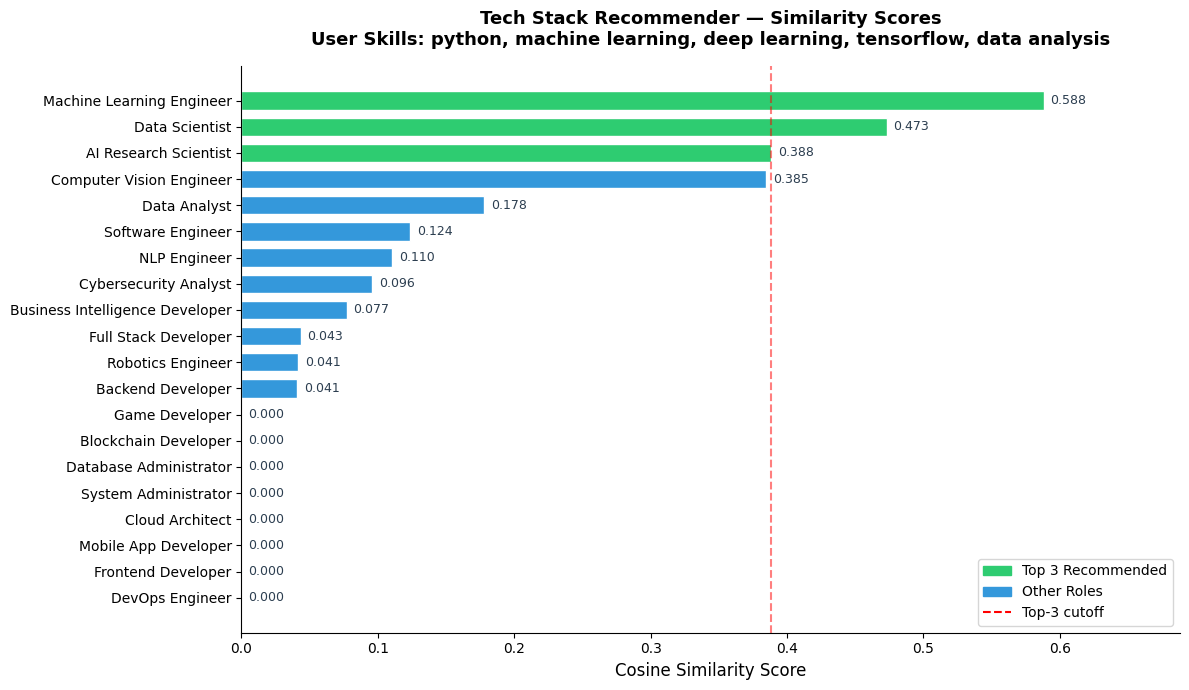

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Get scores for ALL job roles (not just top 3) for full visualization
user_profile_string = ' '.join([s.lower().strip() for s in user_skills_input])
user_vector = tfidf.transform([user_profile_string])
all_scores = cosine_similarity(user_vector, tfidf_matrix).flatten()

# Sort all roles by score
sorted_idx = np.argsort(all_scores)[::-1]
sorted_roles = df['job_role'].values[sorted_idx]
sorted_scores = all_scores[sorted_idx]

# Color: Top-N in green, rest in steelblue
colors = ['#2ecc71' if i < TOP_N else '#3498db' for i in range(len(sorted_roles))]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(sorted_roles[::-1], sorted_scores[::-1], color=colors[::-1], edgecolor='white', height=0.7)

# Add score labels
for bar, score in zip(bars, sorted_scores[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=9, color='#2c3e50')

ax.set_xlabel('Cosine Similarity Score', fontsize=12)
ax.set_title(f'Tech Stack Recommender — Similarity Scores\nUser Skills: {", ".join(user_skills_input)}',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, max(sorted_scores) + 0.1)
ax.axvline(x=sorted_scores[TOP_N-1], color='red', linestyle='--', alpha=0.5, label=f'Top-{TOP_N} cutoff')

green_patch = mpatches.Patch(color='#2ecc71', label=f'Top {TOP_N} Recommended')
blue_patch  = mpatches.Patch(color='#3498db', label='Other Roles')
ax.legend(handles=[green_patch, blue_patch, 
                   plt.Line2D([0], [0], color='red', linestyle='--', label=f'Top-{TOP_N} cutoff')],
          loc='lower right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/similarity_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved!")

In [7]:
# ─── Test Case 1: Cloud & DevOps skills ───
test1 = ["aws", "docker", "kubernetes", "linux", "automation"]

# ─── Test Case 2: Web Development skills ───
test2 = ["html", "css", "javascript", "react", "typescript"]

# ─── Test Case 3: Data & AI skills ───
test3 = ["python", "sql", "machine learning", "pandas", "tableau"]

test_cases = [
    ("☁️  Cloud & DevOps", test1),
    ("🌐 Web Development", test2),
    ("📊 Data & AI", test3),
]

for title, skills in test_cases:
    print(f"\n{'─'*50}")
    print(f"  {title}  |  Skills: {skills}")
    print(f"{'─'*50}")
    result = get_recommendations(skills, top_n=3)
    for _, row in result.iterrows():
        print(f"  #{int(row['Rank'])} {row['Job Role']:<32} → {row['Match %']}")


──────────────────────────────────────────────────
  ☁️  Cloud & DevOps  |  Skills: ['aws', 'docker', 'kubernetes', 'linux', 'automation']
──────────────────────────────────────────────────

 [Step 1: Ingestion] User profile captured
   Skills: ['aws', 'docker', 'kubernetes', 'linux', 'automation']
   Profile string: 'aws docker kubernetes linux automation'

⚙️  [Step 2: Scoring] Cosine similarity computed for all 20 job roles
 [Step 3: Sorting] Results ranked by similarity score (descending)
✂️  [Step 4: Filtering] Truncated to Top-3 results
  #1 DevOps Engineer                  → 61.47%
  #2 Cloud Architect                  → 51.9%
  #3 System Administrator             → 23.78%

──────────────────────────────────────────────────
  🌐 Web Development  |  Skills: ['html', 'css', 'javascript', 'react', 'typescript']
──────────────────────────────────────────────────

 [Step 1: Ingestion] User profile captured
   Skills: ['html', 'css', 'javascript', 'react', 'typescript']
   Profile str

In [8]:
print("=" * 55)
print("  🧊 Cold Start Problem Demonstration")
print("=" * 55)

# Simulate a user with only 1 very generic skill
cold_start_input = ["software", "computer", "coding"]
cold_profile = ' '.join(cold_start_input)
cold_vector = tfidf.transform([cold_profile])
cold_scores = cosine_similarity(cold_vector, tfidf_matrix).flatten()

print(f"  Input skills: {cold_start_input}")
print(f"  All cosine scores: {[round(s, 4) for s in cold_scores]}")
print(f"  Max score: {max(cold_scores):.4f}")
print(f"  Min score: {min(cold_scores):.4f}")
print()

if max(cold_scores) < 0.05:
    print("  ⚠️  LOW CONFIDENCE — Cold Start detected!")
    print("  🔧 Bypass Strategy: Show trending/popular roles instead")
    print("\n  📋 Fallback: Top roles by global popularity:")
    popular_roles = ['Software Engineer', 'Data Scientist', 'Backend Developer']
    for i, role in enumerate(popular_roles, 1):
        print(f"     #{i} {role} (Trending)")
else:
    result = get_recommendations(cold_start_input, top_n=3)
    print(result[['Rank', 'Job Role', 'Match %']].to_string(index=False))

print()
print("  ✅ Cold Start bypass logic implemented!")

  🧊 Cold Start Problem Demonstration
  Input skills: ['software', 'computer', 'coding']
  All cosine scores: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
  Max score: 0.0000
  Min score: 0.0000

  ⚠️  LOW CONFIDENCE — Cold Start detected!
  🔧 Bypass Strategy: Show trending/popular roles instead

  📋 Fallback: Top roles by global popularity:
     #1 Software Engineer (Trending)
     #2 Data Scientist (Trending)
     #3 Backend Developer (Trending)

  ✅ Cold Start bypass logic implemented!
